## Supplementary Figure 4

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/supp_fig4_fb_to_e/`: feedback to E and I, 5 seeds
- `out/fig4_bcp/`: feedback to I only (Figure 4 networks), 5 seeds

Panels b-d simulate untrained networks; the $k_p$ sweep takes a few minutes.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import sys
from functools import partial
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
from diffrax import diffeqsolve, ODETerm, SaveAt, Euler, ConstantStepSize

import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel
from matplotlib.colors import to_rgba
from cmcrameri import cm as cmc

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})
mpl.rc('text.latex', preamble=r'\usepackage{cmbright}')

from bcp.analysis import HydraRunOutput, HydraMultirun, rebuild_traj_run

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())
sys.path.insert(0, str(repo_root))
from run_traj import SimulationRunner

#### Directory setup

In [2]:
fb_to_e_dir = repo_root / "out" / "supp_fig4_fb_to_e"
fb_to_i_dir = repo_root / "out" / "fig4_bcp"
shapes_dir = repo_root / "data" / "shapes"

sfig4_dir = repo_root / "figures" / "supp_fig4"
sfig4_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [3]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh = '#0077B8'
color_inh_ff = '#57CAF1'
color_inputs = '#808285'
color_openloop = 'gray'
color_closedloop = '#F49F1E'
color_target = 'black'
color_accent = 'black'
color_shading = 'gray'

linewidth = 1.0

### Panels e-g: training with and without feedback to E

In [4]:
figsize_perf = (12.5*cm, 2.6*cm)
xticks_time = [0, 180, 360]

In [5]:
tables = {}
for name, path in [('fb_to_e', fb_to_e_dir), ('fb_to_i', fb_to_i_dir)]:
    table = HydraMultirun(path, result_files=['results.pkl']).table(
        keys=['OL_R2', 'CL_error', 'OL_loss', 'training_time'])
    tables[name] = {
        'R2': np.stack(table['OL_R2']),
        'FB': np.abs(np.stack(table['CL_error'])).mean(-1),
        'LOSS': np.stack(table['OL_loss']),
    }
X_TRAINING = table['training_time'][0]

for name, t in tables.items():
    print(f"{name}: final R2 {t['R2'][:, -1].mean():.4f}, final loss {t['LOSS'][:, -1].mean():.5f}")

fb_to_e: final R2 0.9936, final loss 0.00382
fb_to_i: final R2 0.9974, final loss 0.00156


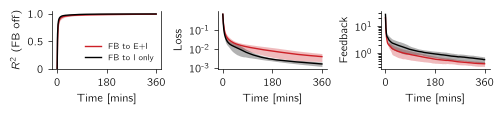

In [6]:
fig = MultiPanel(grid=[3], figsize=figsize_perf, width_ratios=[1, 1, 1])

for name, color, label in [('fb_to_e', color_exc, 'FB to E+I'), ('fb_to_i', 'black', 'FB to I only')]:
    for ax, key in zip(fig.panels, ['R2', 'LOSS', 'FB']):
        mean, std = tables[name][key].mean(0), tables[name][key].std(0)
        ax.plot(X_TRAINING, mean, color=color, lw=linewidth, label=label)
        ax.fill_between(X_TRAINING, mean - std, mean + std, color=color, alpha=0.3, lw=0)

ax = fig.panels[0]
ax.set_ylim(1e-1, 1.05)
ax.spines['right'].set_visible(True)
ax.set_ylabel(r'$R^2$ (FB off)', fontsize=8)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels([0, 0.5, 1.0])
ax.legend(fontsize=6, frameon=False)

ax = fig.panels[1]
ax.set_ylabel(r'Loss', fontsize=8)
ax.set_yscale('log')
ax.set_yticks([1e-3, 1e-2, 1e-1])
ax.set_yticklabels([r'10\textsuperscript{-3}', r'10\textsuperscript{-2}', r'10\textsuperscript{-1}'])

ax = fig.panels[2]
ax.set_ylabel(r'Feedback', fontsize=8)
ax.set_yscale('log')
ax.set_yticks([1e0, 1e1])
ax.set_yticklabels([r'10\textsuperscript{0}', r'10\textsuperscript{1}'])

for ax in fig.panels:
    ax.set_xlabel('Time [mins]')
    ax.set_xticks(xticks_time)
    ax.set_xticklabels(xticks_time)

plt.savefig(sfig4_dir / 'e-g_performance.pdf', bbox_inches='tight')
plt.show()

### Panel h: final training loss

In [7]:
figsize_final_loss = (4.3*cm, 2.6*cm)
ylim_final_loss = (5e-4, 1e-2)

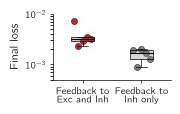

In [8]:
def swarm_box_plot(data_list, labels, figsize, colors, box_width=0.4, box_alpha=0.3,
                   jitter_x=0.3, point_size=20, point_alpha=1.0, ylabel=None):
    # also sets the rcParams used by all later panels
    plt.rcParams.update({
        'font.size': 8,
        'axes.linewidth': 0.5,
        'axes.labelsize': 8,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
        'xtick.major.size': 2,
        'ytick.major.size': 2,
        'lines.linewidth': 0.75,
    })
    fig, ax = plt.subplots(figsize=figsize)
    positions = np.arange(len(data_list))

    for pos, data, color in zip(positions, data_list, colors):
        box_props = dict(facecolor=to_rgba(color, box_alpha), edgecolor='black', linewidth=0.5)
        whisker_props = dict(linewidth=0.5, color='black')
        median_props = dict(linewidth=0.75, color='black')
        ax.boxplot([data], positions=[pos], widths=box_width, patch_artist=True, showfliers=False,
                   boxprops=box_props, whiskerprops=whisker_props, medianprops=median_props,
                   capprops=whisker_props)
        x_jittered = np.linspace(pos - jitter_x / 2, pos + jitter_x / 2, len(data))
        ax.scatter(x_jittered, data, s=point_size, color=color, alpha=point_alpha,
                   edgecolor='black', linewidth=0.3)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    return fig, ax


fig, ax = swarm_box_plot(
    [tables['fb_to_e']['LOSS'][:, -1], tables['fb_to_i']['LOSS'][:, -1]],
    ['Feedback to\nExc and Inh', 'Feedback to\nInh only'],
    figsize=figsize_final_loss,
    colors=[color_exc, 'gray'],
    ylabel=r'Final loss',
)
ax.set_yscale('log')
ax.set_ylim(*ylim_final_loss)

plt.savefig(sfig4_dir / 'h_final_loss.pdf', bbox_inches='tight')
plt.show()

### Panels b-d: controllability of untrained networks

In [9]:
KPS_EXAMPLES = [5, 50, 200]
KPS_SWEEP = np.logspace(-1.0, 2.3, 20)
SEEDS = [1, 2, 3, 4, 5]
EXAMPLE_SEED = 1
figsize_examples = (6.3*cm, 2.0*cm)
figsize_sweep = (4*cm, 3.8*cm)
figsize_sweep_individual = (4.7*cm, 4*cm)

In [10]:
def set_feedback(vectorfield, k_p, feedback_to_excitatory):
    vectorfield.controller.k_p = float(k_p)
    vectorfield.feedback_to_excitatory = bool(feedback_to_excitatory)
    vectorfield.fb_projector = vectorfield._build_fb_projector(
        vectorfield.global_fb,
        vectorfield.random_fb_per_ensemble,
        vectorfield.random_fb_per_neuron,
        vectorfield.only_disinhibitory_feedback,
        vectorfield.feedback_to_excitatory,
    )


def evaluate_closedloop(vectorfield, state, task, cfg):
    # vectorfield is a static jit argument: a fresh runner retraces with the current k_p
    sim = SimulationRunner(vectorfield, Euler(), ConstantStepSize(), cfg.dt, cfg.rec_dt, cfg.T)

    x, y, x_interp, y_interp = task.simulate()
    state, _ = sim(dict(state), x_interp)
    x, y, x_interp, y_interp = task.simulate()
    state, _ = sim.closedloop(state, x_interp, y_interp)
    _, CL_sol = sim.closedloop(state, x_interp, y_interp)
    CL_results = vectorfield.analyze_run(x, CL_sol, cfg.dt, cfg.rec_dt, y, closedloop=True,
                                         W_IE_override=state.get("W_IE", None))

    fb_inh, fb_exc = jax.vmap(vectorfield.fb_projector)(CL_results["ctrl"], CL_sol.ys["W_OUT"])
    total_ctrl = float(jnp.sum(jnp.abs(fb_inh)) + jnp.sum(jnp.abs(fb_exc)))
    return float(CL_results["R2"]), CL_results["uOut"], total_ctrl


# example trajectories
cfg, task, vectorfield = rebuild_traj_run(HydraRunOutput(fb_to_e_dir / f"seed{EXAMPLE_SEED}"), shapes_dir)
state0 = vectorfield.get_initial_state()
target_traj = task.target.get_trajectory()
examples = {}
for fb_to_exc in [False, True]:
    for kp in KPS_EXAMPLES:
        set_feedback(vectorfield, kp, fb_to_exc)
        examples[fb_to_exc, kp] = evaluate_closedloop(vectorfield, state0, task, cfg)[:2]
        jax.clear_caches()

# k_p sweep: [seeds, k_p]
r2 = {False: np.zeros((len(SEEDS), len(KPS_SWEEP))), True: np.zeros((len(SEEDS), len(KPS_SWEEP)))}
ctrl = {False: np.zeros((len(SEEDS), len(KPS_SWEEP))), True: np.zeros((len(SEEDS), len(KPS_SWEEP)))}
for i, seed in enumerate(SEEDS):
    cfg_s, task_s, vf_s = rebuild_traj_run(HydraRunOutput(fb_to_e_dir / f"seed{seed}"), shapes_dir)
    state_s = vf_s.get_initial_state()
    for j, kp in enumerate(KPS_SWEEP):
        for fb_to_exc in [False, True]:
            set_feedback(vf_s, kp, fb_to_exc)
            r2[fb_to_exc][i, j], _, ctrl[fb_to_exc][i, j] = evaluate_closedloop(vf_s, state_s, task_s, cfg_s)
            jax.clear_caches()

timesteps = int(cfg.T / cfg.dt)
ctrl_per_step = {k: v / timesteps for k, v in ctrl.items()}

/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg


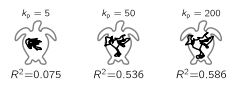

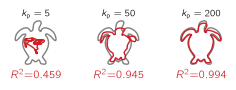

In [11]:
for fb_to_exc, name in [(False, 'fb_to_i'), (True, 'fb_to_e')]:
    fig, axes = plt.subplots(1, 3, figsize=figsize_examples)
    line_color = color_exc if fb_to_exc else 'black'

    for ax, kp in zip(axes, KPS_EXAMPLES):
        CL_R2, CL_out = examples[fb_to_exc, kp]
        ax.plot(CL_out[:, 0], CL_out[:, 1], color=line_color, lw=linewidth)
        ax.plot(target_traj[:, 0], target_traj[:, 1], color='gray', lw=linewidth, zorder=-1)
        ax.axis('off')
        ax.set_aspect('equal', adjustable='box', anchor='SE')
        ax.set_title(rf'$k_\mathrm{{p}}={int(kp)}$', fontsize=7, pad=1)
        ax.text(0.5, -0.05, rf'$R^2$={CL_R2:.3f}', fontsize=8, color=line_color,
                ha='center', va='top', transform=ax.transAxes)

    plt.savefig(sfig4_dir / f'b_trajectories_{name}.pdf', bbox_inches='tight')
    plt.show()

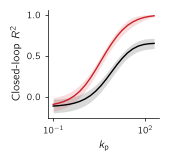

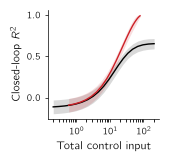

In [12]:
for panel, xs, xlabel in [('c_cl_r2_vs_kp', {False: KPS_SWEEP, True: KPS_SWEEP}, r'$k_\mathrm{p}$'),
                          ('d_cl_r2_vs_control', {k: v.mean(0) for k, v in ctrl_per_step.items()}, r'Total control input')]:
    fig, ax = plt.subplots(1, 1, figsize=figsize_sweep)
    for fb_to_exc, color in [(False, 'black'), (True, color_exc)]:
        mean, std = r2[fb_to_exc].mean(0), r2[fb_to_exc].std(0)
        ax.plot(xs[fb_to_exc], mean, color=color, lw=linewidth)
        ax.fill_between(xs[fb_to_exc], mean - std, mean + std, color=color, alpha=0.15, linewidth=0, zorder=-1)
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Closed-loop $R^2$')

    plt.savefig(sfig4_dir / f'{panel}.pdf', bbox_inches='tight')
    plt.show()

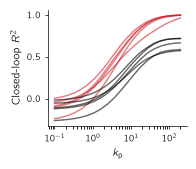

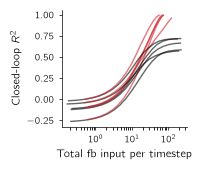

In [13]:
# individual networks (not used in the paper)
for panel, xs, xlabel in [('NA_c_cl_r2_vs_kp_individual', {False: [KPS_SWEEP] * len(SEEDS), True: [KPS_SWEEP] * len(SEEDS)}, r'$k_\mathrm{p}$'),
                          ('NA_d_cl_r2_vs_control_individual', ctrl_per_step, r'Total fb input per timestep')]:
    fig, ax = plt.subplots(1, 1, figsize=figsize_sweep_individual)
    for i in range(len(SEEDS)):
        ax.plot(xs[False][i], r2[False][i], color='black', lw=linewidth, alpha=0.6)
        ax.plot(xs[True][i], r2[True][i], color=color_exc, lw=linewidth, alpha=0.6)
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Closed-loop $R^2$')

    plt.savefig(sfig4_dir / f'{panel}.pdf', bbox_inches='tight')
    plt.show()